In [55]:
#pip install yfinance

In [117]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from datetime import date

In [121]:
def vol_check():
    tickers = input("provide tickers to visualize volatility: ").replace(" ","")
    
    ticker_list = tickers.split(",")
    for i in range(len(ticker_list)):
        ticker_list[i] = ticker_list[i].upper()
    
    today = date.today()
    lookback = (str(today.year-2)+'-'+str(today.month)+'-'+str(today.day))
    lookback_date = datetime.strptime(lookback, '%Y-%m-%d').date()
    
    plt.figure(figsize=(12, 6))
    
    for i in range(len(ticker_list)):
        data = yf.download(ticker_list[i], start=lookback_date, end=today-timedelta(days=1))
        data.reset_index()
        data['log_close']=np.log(data['Close'])
        data['log_returns'] = data['log_close']-data['log_close'].shift(1)
        data['std_dev'] = data['log_returns'].rolling(30,axis=0).std() 
    
        plt.title("Volatility of Selected Equities, 30 Day Rolling Window")
        plt.plot(data['std_dev'])
        plt.xticks(rotation=25)
        plt.xlabel("Date")
        plt.ylabel("Std. Dev. of Ticker Returns")
        plt.legend(ticker_list,loc='upper right')
    
        plt.tight_layout()  

provide tickers to visualize volatility:  tsla, googl, meta, aapl, nflx


/tmp/ipykernel_571/3331442578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_list[i], start=lookback_date, end=today-timedelta(days=1))
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_571/3331442578.py:19: FutureWarning: The 'axis' keyword in Series.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  data['std_dev'] = data['log_returns'].rolling(30,axis=0).std()
/tmp/ipykernel_571/3331442578.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker_list[i], start=lookback_date, end=today-timedelta(days=1))
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_571/3331442578.py:19: FutureWarning: The 'axis' keyword in Series.rolling is deprecated and will be removed in a future version. Call the method without the axis keyword instead.
  dat

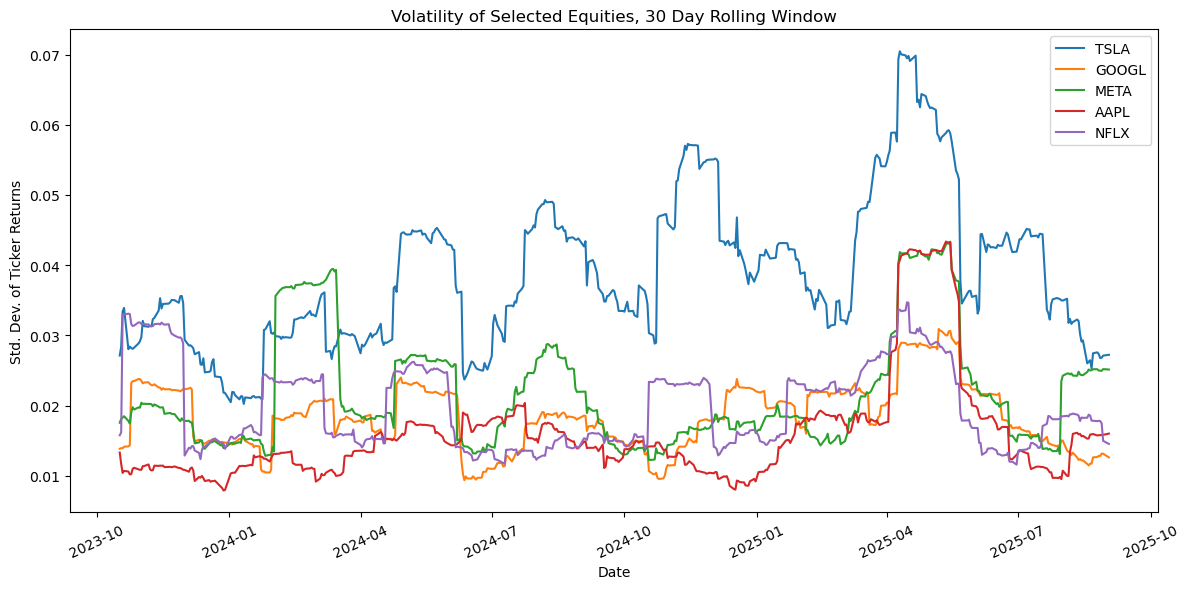

In [122]:
vol_check()